In [1]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import csv
import os
import sys
sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
import lumapi

In [2]:
class PWBParameters:
    def __init__(self):
        # LNOI结构
        # 第一层taper：x(0,60)长度60um，宽度1um-->0.4um，z(0.3,0.6)厚度0.3um
        # 第二层taper：x(0,80)长度80um，宽度6um-->0.4um，z(0，0.3)厚度0.3um
        self.h1 = 1.3e-6
        self.h2 = 1.5e-6
        self.w1 = 3.5e-6
        self.w2 = 3e-6
        self.l = 80e-6
        self.wavelength = 1.55e-6
        self.mesh_accuracy = 1 
        self.simulation_time = 2000e-15 

In [3]:
def create_pwb_structure_in_fdtd(fdtd,params):
    """在FDTD中创建PWB结构"""
    [h1, h2, w1, w2, l] = [params.h1, params.h2, params.w1, params.w2, params.l]
    
    fdtd.deleteall()
    fdtd.load("D:/simulation/Simulation Project/simulation/LNOI-PWB-SMF/LNOI.fsp")
    fdtd.importmaterialdb("D:/simulation/Simulation Project/simulation/database.mdf")

    fdtd.addpyramid()
    fdtd.set("name", "PWB")
    fdtd.set("material", "Vancore B")
    fdtd.set("override mesh order from material database",1)
    fdtd.set("mesh order",3)
    fdtd.set("override color opacity from material database", 1)
    fdtd.set("alpha", 0.5)
    fdtd.set("x", l/2)
    fdtd.set("x span bottom", 2*h1)
    fdtd.set("x span top", 2*h2)
    fdtd.set("y", 0)
    fdtd.set("y span bottom", w1)
    fdtd.set("y span top", w2)
    fdtd.set("z", 0)
    fdtd.set("z span", l)
    fdtd.set("first axis", "y")
    fdtd.set("rotation 1", 90)

    fdtd.addrect()
    fdtd.set("name", "PWB-Straight")
    fdtd.set("material", "Vancore B")
    fdtd.set("override mesh order from material database", 1)
    fdtd.set("mesh order",3)
    fdtd.set("override color opacity from material database", 1)
    fdtd.set("alpha", 0.5)
    fdtd.set("x", 15e-6 + l)
    fdtd.set("x span", 30e-6)
    fdtd.set("y", 0)
    fdtd.set("y span", w2)
    fdtd.set("z", h2/2)
    fdtd.set("z span", h2)

In [4]:
def setup_fdtd_simulation(fdtd, params):
    """设置FDTD仿真参数"""
    [h1, h2, w1, w2, l] = [params.h1, params.h2, params.w1, params.w2, params.l]
    # 扩展仿真边界
    margin = 2e-6
    
    # 添加FDTD仿真区域
    fdtd.addfdtd()
    fdtd.set("dimension", "3D")
    fdtd.set("x min", -10e-6)
    fdtd.set("x max", 95e-6)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)
    fdtd.set("y min", -w2/2 - margin)
    fdtd.set("y max", w2/2 + margin)
    fdtd.set("x min bc", "PML")
    fdtd.set("x max bc", "PML")
    fdtd.set("y min bc", "PML")
    fdtd.set("y max bc", "PML")
    fdtd.set("z min bc", "PML")
    fdtd.set("z max bc", "PML")
    fdtd.set("mesh accuracy", params.mesh_accuracy)
    fdtd.set("mesh type", "auto non-uniform")
    fdtd.set("simulation time", params.simulation_time)
    
    # 添加光源
    fdtd.addmode()
    fdtd.set("name", "source")
    fdtd.set("injection axis", "x-axis")
    fdtd.set("direction", "forward")
    fdtd.set("x", -5e-6)
    fdtd.set("y min", -w2/2 - margin)
    fdtd.set("y max", w2/2 + margin)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)
    fdtd.set("mode selection", "fundamental TE mode")
    fdtd.set("wavelength start", params.wavelength)
    fdtd.set("wavelength stop", params.wavelength)

    fdtd.addpower()
    fdtd.set("name", "monitor_0")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", 0)
    fdtd.set("y min", -w2/2 - margin)
    fdtd.set("y max", w2/2 + margin)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)

    fdtd.addpower()
    fdtd.set("name", "monitor_60")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", 60e-6)
    fdtd.set("y min", -w2/2 - margin)
    fdtd.set("y max", w2/2 + margin)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)

    fdtd.addpower()
    fdtd.set("name", "monitor_80")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", 80e-6)
    fdtd.set("y min", -w2/2 - margin)
    fdtd.set("y max", w2/2 + margin)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)

    fdtd.addpower()
    fdtd.set("name", "monitor_90")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", 90e-6)
    fdtd.set("y min", -w2/2 - margin)
    fdtd.set("y max", w2/2 + margin)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)

    # 添加模式分析
    fdtd.addmodeexpansion()
    fdtd.set("name", "mode_expansion")
    fdtd.setexpansion("output", "monitor_90")
    fdtd.set("mode selection", "fundamental TE mode")
    fdtd.set("x", 90e-6)
    fdtd.set("y min", -w2/2 - margin)
    fdtd.set("y max", w2/2 + margin)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)
    
    # 添加场分布监视器
    fdtd.addpower()
    fdtd.set("name", "transmission_monitor")
    fdtd.set("monitor type", "2D Y-normal")
    fdtd.set("y", 0)
    fdtd.set("x min", -10e-6)
    fdtd.set("x max", 95e-6)
    fdtd.set("z min", -2e-6)
    fdtd.set("z max", h2 + margin)

In [5]:
def get_data(fdtd, params):
    """运行仿真并分析结果"""

    source_E = fdtd.getresult("source", "mode profile")
    transmission_E = fdtd.getresult("transmission_monitor", "E")
    monitor_0_E = fdtd.getresult("monitor_0", "E")
    monitor_60_E = fdtd.getresult("monitor_60", "E")
    monitor_80_E = fdtd.getresult("monitor_80", "E")
    monitor_90_E = fdtd.getresult("monitor_90", "E")
    mode_data = fdtd.getresult("mode_expansion", "expansion for output")
    T_forward = mode_data["T_forward"][0][0]
    
    results = {
        'source_E': source_E,
        'transmission_E': transmission_E,
        'monitor_0_E': monitor_0_E,
        'monitor_60_E': monitor_60_E,
        'monitor_80_E': monitor_80_E,
        'monitor_90_E': monitor_90_E,
        'T_forward': T_forward
    }
    
    return results

In [6]:
def visualize_and_save_results(fdtd, params):
    """可视化结果并保存T_forward数据"""
    
    # 获取数据
    results = get_data(fdtd, params)
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    ax1, ax2, ax3 = axes[0]
    ax4, ax5, ax6 = axes[1]

    # source的E场 (2D X-normal)
    source_E = results['source_E']
    E_source = source_E['E']
    Ex_source = E_source[0, :, :, 0, 0]
    Ey_source = E_source[0, :, :, 0, 1]
    Ez_source = E_source[0, :, :, 0, 2]
    E_suorce_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
    y_source = np.squeeze(source_E['y']) * 1e6 #移除长度为1的维度
    z_source = np.squeeze(source_E['z']) * 1e6
    Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
    im1 = ax1.pcolormesh(Y_source, Z_source, E_suorce_abs, cmap="jet", shading='auto')
    ax1.set_xlabel('Y (μm)')
    ax1.set_ylabel('Z (μm)')
    ax1.set_title('Source')

    monitor_0_E = results['monitor_0_E']
    E_field_monitor_0 = monitor_0_E['E']
    Ex_monitor_0 = E_field_monitor_0[0, :, :, 0, 0]
    Ey_monitor_0 = E_field_monitor_0[0, :, :, 0, 1]
    Ez_monitor_0 = E_field_monitor_0[0, :, :, 0, 2]
    E_intensity_monitor_0 = np.abs(Ex_monitor_0)**2 + np.abs(Ey_monitor_0)**2 + np.abs(Ez_monitor_0)**2
    y_input = np.squeeze(monitor_0_E['y']) * 1e6
    z_input = np.squeeze(monitor_0_E['z']) * 1e6
    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
    im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_monitor_0, cmap="jet", shading='auto')
    ax2.set_xlabel('Y (μm)')
    ax2.set_ylabel('Z (μm)')
    ax2.set_title('Monitor_0')

    monitor_60_E = results['monitor_60_E']
    E_field_monitor_60 = monitor_60_E['E']
    Ex_monitor_60 = E_field_monitor_60[0, :, :, 0, 0]
    Ey_monitor_60 = E_field_monitor_60[0, :, :, 0, 1]
    Ez_monitor_60 = E_field_monitor_60[0, :, :, 0, 2]
    E_intensity_monitor_60 = np.abs(Ex_monitor_60)**2 + np.abs(Ey_monitor_60)**2 + np.abs(Ez_monitor_60)**2
    y_input = np.squeeze(monitor_60_E['y']) * 1e6
    z_input = np.squeeze(monitor_60_E['z']) * 1e6
    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
    im3 = ax3.pcolormesh(Y_input, Z_input, E_intensity_monitor_60, cmap="jet", shading='auto')
    ax3.set_xlabel('Y (μm)')
    ax3.set_ylabel('Z (μm)')
    ax3.set_title('Monitor_60')

    monitor_80_E = results['monitor_80_E']
    E_field_monitor_80 = monitor_80_E['E']
    Ex_monitor_80 = E_field_monitor_80[0, :, :, 0, 0]
    Ey_monitor_80 = E_field_monitor_80[0, :, :, 0, 1]
    Ez_monitor_80 = E_field_monitor_80[0, :, :, 0, 2]
    E_intensity_monitor_80 = np.abs(Ex_monitor_80)**2 + np.abs(Ey_monitor_80)**2 + np.abs(Ez_monitor_80)**2
    y_input = np.squeeze(monitor_80_E['y']) * 1e6
    z_input = np.squeeze(monitor_80_E['z']) * 1e6
    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
    im4 = ax4.pcolormesh(Y_input, Z_input, E_intensity_monitor_80, cmap="jet", shading='auto')
    ax4.set_xlabel('Y (μm)')
    ax4.set_ylabel('Z (μm)')
    ax4.set_title('Monitor_80')

    monitor_90_E = results['monitor_90_E']
    E_field_monitor_90 = monitor_90_E['E']
    Ex_monitor_90 = E_field_monitor_90[0, :, :, 0, 0]
    Ey_monitor_90 = E_field_monitor_90[0, :, :, 0, 1]
    Ez_monitor_90 = E_field_monitor_90[0, :, :, 0, 2]
    E_intensity_monitor_90 = np.abs(Ex_monitor_90)**2 + np.abs(Ey_monitor_90)**2 + np.abs(Ez_monitor_90)**2
    y_input = np.squeeze(monitor_90_E['y']) * 1e6
    z_input = np.squeeze(monitor_90_E['z']) * 1e6
    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
    im5 = ax5.pcolormesh(Y_input, Z_input, E_intensity_monitor_90, cmap="jet", shading='auto')
    ax5.set_xlabel('Y (μm)')
    ax5.set_ylabel('Z (μm)')
    ax5.set_title('Monitor_90')

    trans_E = results['transmission_E']
    E_field = trans_E['E']
    Ex = E_field[:, 0, :, 0, 0]
    Ey = E_field[:, 0, :, 0, 1]
    Ez = E_field[:, 0, :, 0, 2]
    E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    x_trans = np.squeeze(trans_E['x']) * 1e6 
    z_trans = np.squeeze(trans_E['z']) * 1e6 
    X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
    im6 = ax6.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
    ax6.set_xlabel('X (μm)')
    ax6.set_ylabel('Z (μm)')
    ax6.set_title('Transmission Monitor')
    plt.suptitle("Field")
    plt.tight_layout()
    plt.show()

    T_forward = results['T_forward']

    return T_forward

In [7]:
# 单次仿真test
params = PWBParameters()
fdtd = lumapi.FDTD()
create_pwb_structure_in_fdtd(fdtd, params)
setup_fdtd_simulation(fdtd, params)
fdtd.save(r"D:\simulation\Simulation Project\simulation\LNOI-PWB-SMF\test.fsp")

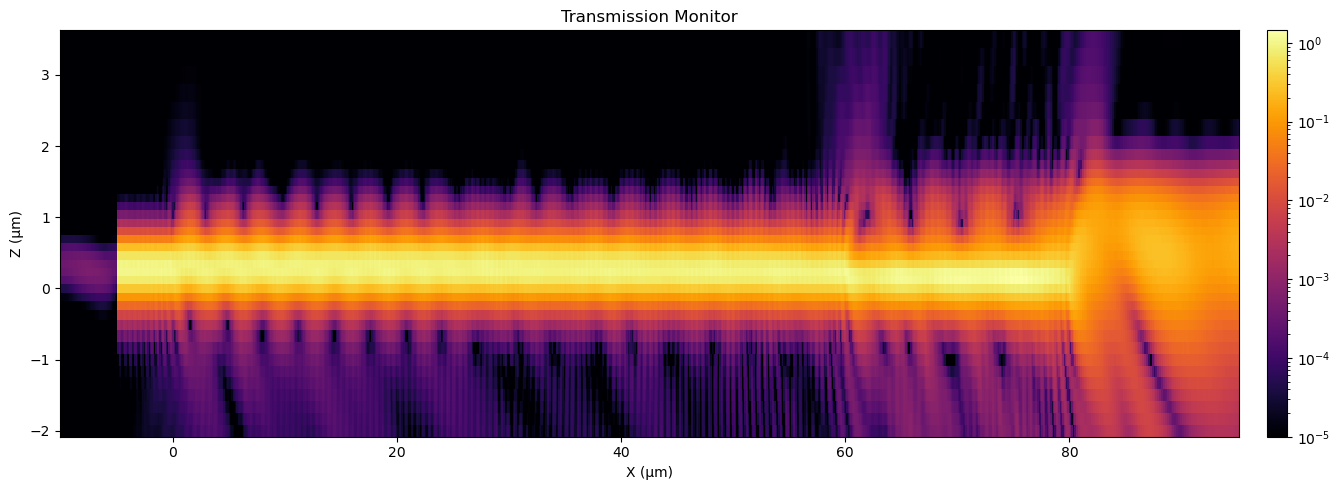

In [8]:
transmission_E = fdtd.getresult("transmission_monitor", "E")
fig, ax = plt.subplots(figsize=(15, 5))
trans_E = transmission_E
E_field = trans_E['E']
Ex = E_field[:, 0, :, 0, 0]
Ey = E_field[:, 0, :, 0, 1]
Ez = E_field[:, 0, :, 0, 2]
E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
x_trans = np.squeeze(trans_E['x']) * 1e6  # (381,)
z_trans = np.squeeze(trans_E['z']) * 1e6  # (101,)
X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')

vmin = 1e-5
vmax = np.nanmax(E_intensity_trans)
data_to_plot = E_intensity_trans
norm = LogNorm(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(X_trans, Z_trans, data_to_plot, cmap="inferno", shading='auto', norm=norm)
cbar = fig.colorbar(pcm, ax=ax, pad=0.02, format=ticker.LogFormatterSciNotation())
ax.set_xlabel('X (μm)')
ax.set_ylabel('Z (μm)')
ax.set_title('Transmission Monitor')

plt.tight_layout()
plt.show()

In [ ]:
# fdtd.run()
get_data(fdtd, params)
T_forward = visualize_and_save_results(fdtd, params)
print(T_forward)

In [9]:
fdtd.close()

In [8]:
results_dir = "D:/simulation/Simulation Project/simulation/LNOI-PWB-SMF/results/h1_h2_w1_w2_scan"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
results_file = os.path.join(results_dir, "T_forward_results.csv")
file_exists = os.path.isfile(results_file)
with open(results_file, 'a', newline='') as csvfile:
    fieldnames = ['h1', 'h2', 'w1', 'w2', 'T_forward']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

# 定义参数范围
h1_values = np.arange(0.7, 1.7, 0.2) * 1e-6  # h1: 0.7um to 1.5um, step 0.2um
h2_values = np.arange(0.7, 1.7, 0.2) * 1e-6  # h2: 0.7um to 1.5um, step 0.2um
w1_values = np.arange(1.5, 4, 0.5) * 1e-6  # w1: 1.5um to 3.5um, step 0.5um
w2_values = np.arange(1.5, 4, 0.5) * 1e-6  # w2: 1.5um to 3.5um, step 0.5um

# 开始参数扫描
for h1 in h1_values:
    for h2 in h2_values:
        for w1 in w1_values:
            for w2 in w2_values:
                print(f"Processing h1={h1*1e6:.1f}μm, h2={h2*1e6:.1f}μm, w1={w1*1e6:.1f}μm, w2={w2*1e6:.1f}μm")

                # 更新参数
                params = PWBParameters()
                params.h1 = h1
                params.h2 = h2
                params.w1 = w1
                params.w2 = w2
                fdtd = lumapi.FDTD()
                create_pwb_structure_in_fdtd(fdtd, params)
                setup_fdtd_simulation(fdtd, params)
                fdtd.save("temp.fsp")
                fdtd.run()

                # 获取仿真结果
                results = get_data(fdtd, params)
                T_forward = results['T_forward']

                 # 保存结果到CSV文件
                with open(results_file, 'a', newline='') as csvfile:
                    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                    writer.writerow({
                        'h1': h1 * 1e6,
                        'h2': h2 * 1e6,
                        'w1': w1 * 1e6,
                        'w2': w2 * 1e6,
                        'T_forward': T_forward
                    })

                # 保存图片
                try:
                    results = get_data(fdtd, params)
                    plt.rcParams['font.family'] = 'Times New Roman'
                    plt.rcParams['xtick.labelsize'] = 12
                    plt.rcParams['ytick.labelsize'] = 12
                    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
                    ax1, ax2, ax3 = axes[0]
                    ax4, ax5, ax6 = axes[1]

                    # source的E场 (2D X-normal)
                    source_E = results['source_E']
                    E_source = source_E['E']
                    Ex_source = E_source[0, :, :, 0, 0]
                    Ey_source = E_source[0, :, :, 0, 1]
                    Ez_source = E_source[0, :, :, 0, 2]
                    E_suorce_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
                    y_source = np.squeeze(source_E['y']) * 1e6 #移除长度为1的维度
                    z_source = np.squeeze(source_E['z']) * 1e6
                    Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
                    im1 = ax1.pcolormesh(Y_source, Z_source, E_suorce_abs, cmap="jet", shading='auto')
                    ax1.set_xlabel('Y (μm)')
                    ax1.set_ylabel('Z (μm)')
                    ax1.set_title('Source')

                    monitor_0_E = results['monitor_0_E']
                    E_field_monitor_0 = monitor_0_E['E']
                    Ex_monitor_0 = E_field_monitor_0[0, :, :, 0, 0]
                    Ey_monitor_0 = E_field_monitor_0[0, :, :, 0, 1]
                    Ez_monitor_0 = E_field_monitor_0[0, :, :, 0, 2]
                    E_intensity_monitor_0 = np.abs(Ex_monitor_0)**2 + np.abs(Ey_monitor_0)**2 + np.abs(Ez_monitor_0)**2
                    y_input = np.squeeze(monitor_0_E['y']) * 1e6
                    z_input = np.squeeze(monitor_0_E['z']) * 1e6
                    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
                    im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_monitor_0, cmap="jet", shading='auto')
                    ax2.set_xlabel('Y (μm)')
                    ax2.set_ylabel('Z (μm)')
                    ax2.set_title('Monitor_0')

                    monitor_60_E = results['monitor_60_E']
                    E_field_monitor_60 = monitor_60_E['E']
                    Ex_monitor_60 = E_field_monitor_60[0, :, :, 0, 0]
                    Ey_monitor_60 = E_field_monitor_60[0, :, :, 0, 1]
                    Ez_monitor_60 = E_field_monitor_60[0, :, :, 0, 2]
                    E_intensity_monitor_60 = np.abs(Ex_monitor_60)**2 + np.abs(Ey_monitor_60)**2 + np.abs(Ez_monitor_60)**2
                    y_input = np.squeeze(monitor_60_E['y']) * 1e6
                    z_input = np.squeeze(monitor_60_E['z']) * 1e6
                    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
                    im3 = ax3.pcolormesh(Y_input, Z_input, E_intensity_monitor_60, cmap="jet", shading='auto')
                    ax3.set_xlabel('Y (μm)')
                    ax3.set_ylabel('Z (μm)')
                    ax3.set_title('Monitor_60')

                    monitor_80_E = results['monitor_80_E']
                    E_field_monitor_80 = monitor_80_E['E']
                    Ex_monitor_80 = E_field_monitor_80[0, :, :, 0, 0]
                    Ey_monitor_80 = E_field_monitor_80[0, :, :, 0, 1]
                    Ez_monitor_80 = E_field_monitor_80[0, :, :, 0, 2]
                    E_intensity_monitor_80 = np.abs(Ex_monitor_80)**2 + np.abs(Ey_monitor_80)**2 + np.abs(Ez_monitor_80)**2
                    y_input = np.squeeze(monitor_80_E['y']) * 1e6
                    z_input = np.squeeze(monitor_80_E['z']) * 1e6
                    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
                    im4 = ax4.pcolormesh(Y_input, Z_input, E_intensity_monitor_80, cmap="jet", shading='auto')
                    ax4.set_xlabel('Y (μm)')
                    ax4.set_ylabel('Z (μm)')
                    ax4.set_title('Monitor_80')

                    monitor_90_E = results['monitor_90_E']
                    E_field_monitor_90 = monitor_90_E['E']
                    Ex_monitor_90 = E_field_monitor_90[0, :, :, 0, 0]
                    Ey_monitor_90 = E_field_monitor_90[0, :, :, 0, 1]
                    Ez_monitor_90 = E_field_monitor_90[0, :, :, 0, 2]
                    E_intensity_monitor_90 = np.abs(Ex_monitor_90)**2 + np.abs(Ey_monitor_90)**2 + np.abs(Ez_monitor_90)**2
                    y_input = np.squeeze(monitor_90_E['y']) * 1e6
                    z_input = np.squeeze(monitor_90_E['z']) * 1e6
                    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
                    im5 = ax5.pcolormesh(Y_input, Z_input, E_intensity_monitor_90, cmap="jet", shading='auto')
                    ax5.set_xlabel('Y (μm)')
                    ax5.set_ylabel('Z (μm)')
                    ax5.set_title('Monitor_90')

                    trans_E = results['transmission_E']
                    E_field = trans_E['E']
                    Ex = E_field[:, 0, :, 0, 0]
                    Ey = E_field[:, 0, :, 0, 1]
                    Ez = E_field[:, 0, :, 0, 2]
                    E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
                    x_trans = np.squeeze(trans_E['x']) * 1e6 
                    z_trans = np.squeeze(trans_E['z']) * 1e6 
                    X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
                    im6 = ax6.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
                    ax6.set_xlabel('X (μm)')
                    ax6.set_ylabel('Z (μm)')
                    ax6.set_title('Transmission Monitor')

                    plt.suptitle(f"h1={h1*1e6:.1f}μm, h2={h2*1e6:.1f}μm, w1={w1*1e6:.1f}μm, w2={w2*1e6:.1f}μm")
                    plt.tight_layout()

                    # 保存图片
                    fig_path = os.path.join(results_dir, f"h1_{h1*1e6:.1f}_h2_{h2*1e6:.1f}_w1_{w1*1e6:.1f}_w2_{w2*1e6:.1f}.jpg")
                    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
                    plt.close()

                    print("T_forward:", T_forward)

                except Exception as e:
                    print(f"Error while saving plot: {e}")

print("Parameter scan completed. Results saved.")

Processing h1=0.7μm, h2=0.7μm, w1=1.5μm, w2=1.5μm
T_forward: 0.1423640467588171
Processing h1=0.7μm, h2=0.7μm, w1=1.5μm, w2=2.0μm
T_forward: 0.28321794279180845
Processing h1=0.7μm, h2=0.7μm, w1=1.5μm, w2=2.5μm
T_forward: 0.35515483852800217
Processing h1=0.7μm, h2=0.7μm, w1=1.5μm, w2=3.0μm
T_forward: 0.3993925920430448
Processing h1=0.7μm, h2=0.7μm, w1=1.5μm, w2=3.5μm
T_forward: 0.39878868457375827
Processing h1=0.7μm, h2=0.7μm, w1=2.0μm, w2=1.5μm
T_forward: 0.14205763924794906
Processing h1=0.7μm, h2=0.7μm, w1=2.0μm, w2=2.0μm
T_forward: 0.28302045137145576
Processing h1=0.7μm, h2=0.7μm, w1=2.0μm, w2=2.5μm
T_forward: 0.3511476997606942
Processing h1=0.7μm, h2=0.7μm, w1=2.0μm, w2=3.0μm
T_forward: 0.3980614411889216
Processing h1=0.7μm, h2=0.7μm, w1=2.0μm, w2=3.5μm
T_forward: 0.40202295555552875
Processing h1=0.7μm, h2=0.7μm, w1=2.5μm, w2=1.5μm
T_forward: 0.1414644992352944
Processing h1=0.7μm, h2=0.7μm, w1=2.5μm, w2=2.0μm
T_forward: 0.27961261046185476
Processing h1=0.7μm, h2=0.7μm, w1

LumApiError: "Can not find result 'E' in the result provider 'transmission_monitor'"